## T3:  Graphene
We now turn to graphene, which is a well-known hexagonal crystal structure. The new thing we will have to deal with for this example, is the need for $\vec{k}$-point sampling. It gives us some more equations to propagate, but it is just more of the same type of problem as we dealt with in the chain-example. Here we just sample five points and look at the differences. Beyond this, the procedure is the same. We proceed to do much of what has been covered previously in the next lines of code, and the geometry creation, Fermi-expansion and calls to TBtrans should be familiar. The calculation is very coarse and should not be taken as a good graphene calculation, but as a demonstration of how to propagate decoupled systems

/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['number']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site

Running TB-Trans in Directory: Device!



dep:0: SislDeprecation: tbtncSileTBtrans.geom is deprecated, please use '.geometry'.0.14 [>=0.16]


Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)
Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)
Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)
Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)
Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)

 Building ES - H - Self Energies 

[0, 1, 2, 3, 4]
Using S = S

 Overlap Included!

Using S = S
Using S = S
Using S = S
Using S = S


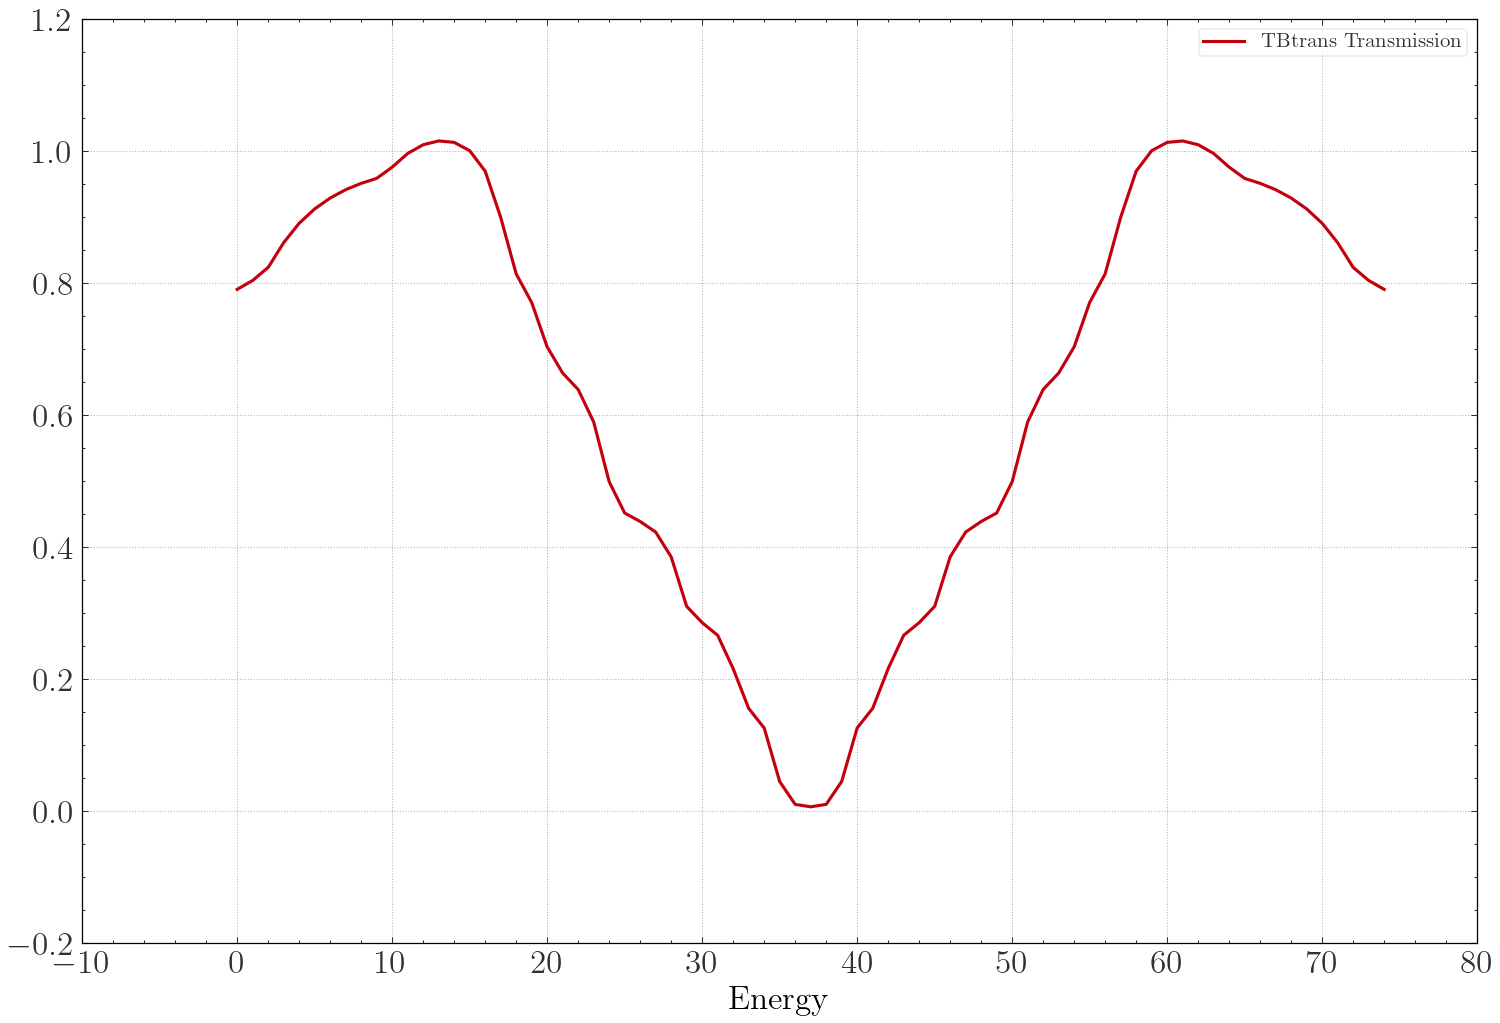

In [9]:
import sisl
import matplotlib.pyplot as plt
import numpy as np
from Zandpack.TimedependentTransport import TD_Transport as TDT
import matplotlib.image as img
plt.rcParams['figure.figsize']  = [12,8]
%matplotlib inline
tx     = 3
ty     = 2
t_elec = -2.7
t_dev  = -2.7

g = sisl.geom.graphene(orthogonal = True).tile(ty,1)
geom_dev = g.tile(tx+2,0)#.add_vacuum(10,1)
geom_em  = g.copy()
geom_ep  = g.move((tx+1) * g.cell[0,:])

# sisl.plot(geom_dev); plt.axis('equal'); plt.show()
eta = 1e-1
line = np.vstack([np.linspace(-5,5,75) + 1j * eta]*2)
Test = TDT([geom_em,geom_ep], geom_dev, kT_i = [0.05, 0.05])
Test.Make_Contour(line, 12, pole_mode = 'JieHu2011')

ky = 8
Test.Electrodes( semi_infs = ['-a1', '+a1'] , kp = [[50,ky,1],[50,ky,1]])
Test.make_device(elec_inds = [[i for i in range(geom_em.na)], 
                              [4*(tx+1)*ty+i for i in range(geom_em.na)]], 
                 k = [1,ky,1], k_tbtrans = [1,ky,1])

elec = sisl.Hamiltonian(geom_em)
elec.construct([[0.1, 1.5], 
                [0,   t_dev] ])


Test.run_electrodes(manual_H = [elec, elec])
dev_H = sisl.Hamiltonian(geom_dev)
dev_H.construct([[0.1, 1.5], 
                 [0,   t_dev] ])

Test.run_device(manual_H = dev_H)
Test.read_data()
plt.show()
plt.plot(Test.tbtT[Test.sampling_idx[0]], label = 'TBtrans Transmission')
plt.xlabel('Energy')
plt.legend()
plt.show()

Normal plot

 Subbed transmission vs TBtrans transmission. 



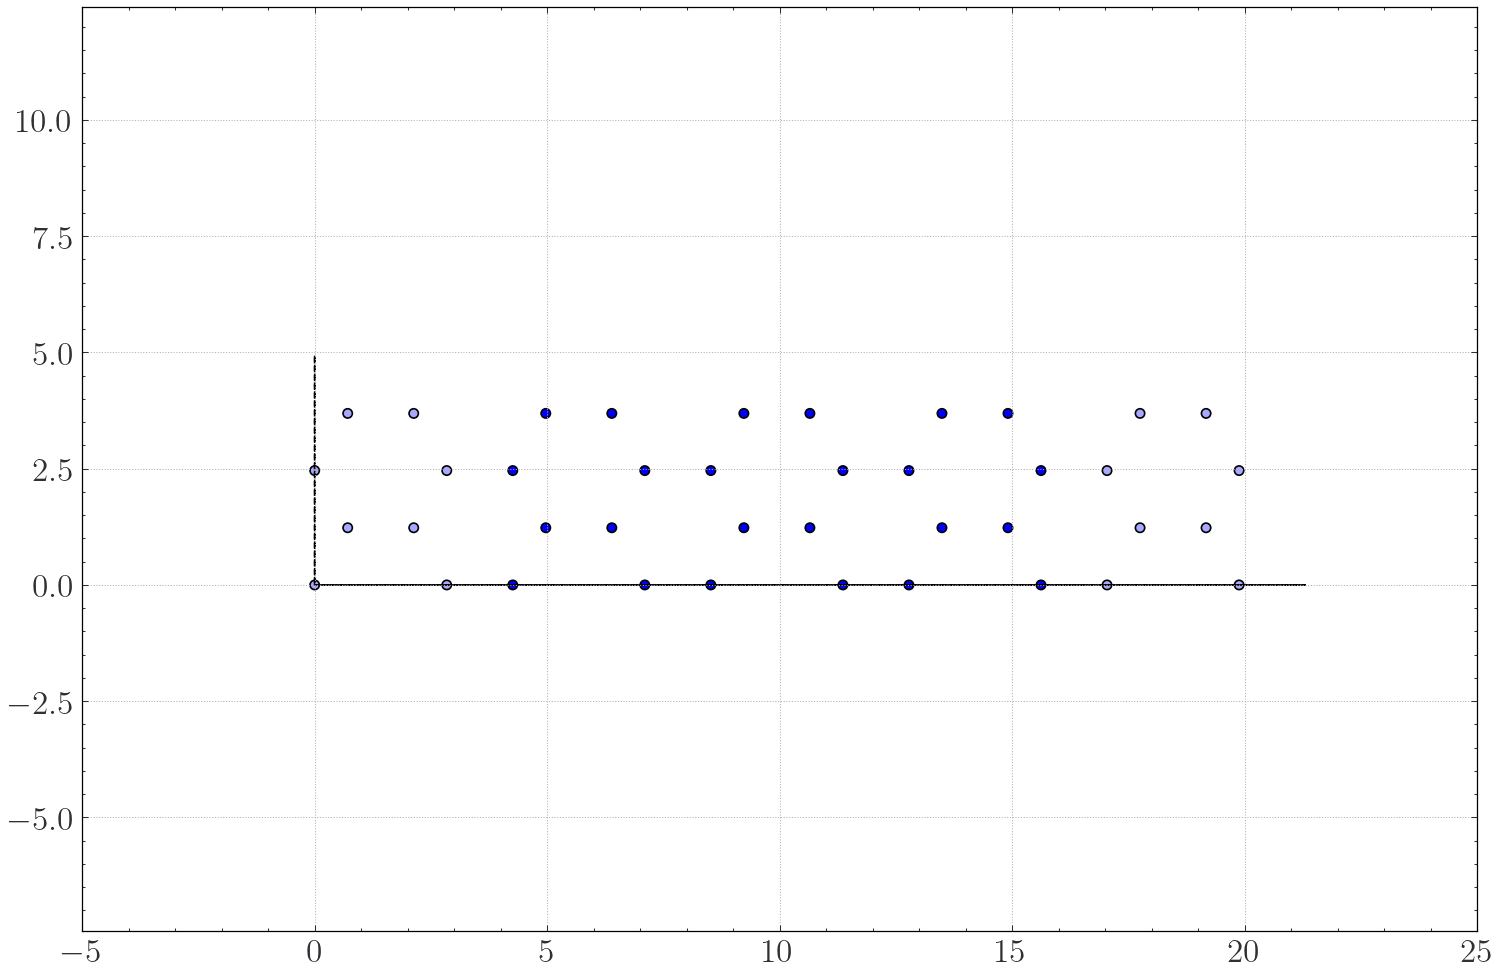

/home/investigator/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/investigator/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


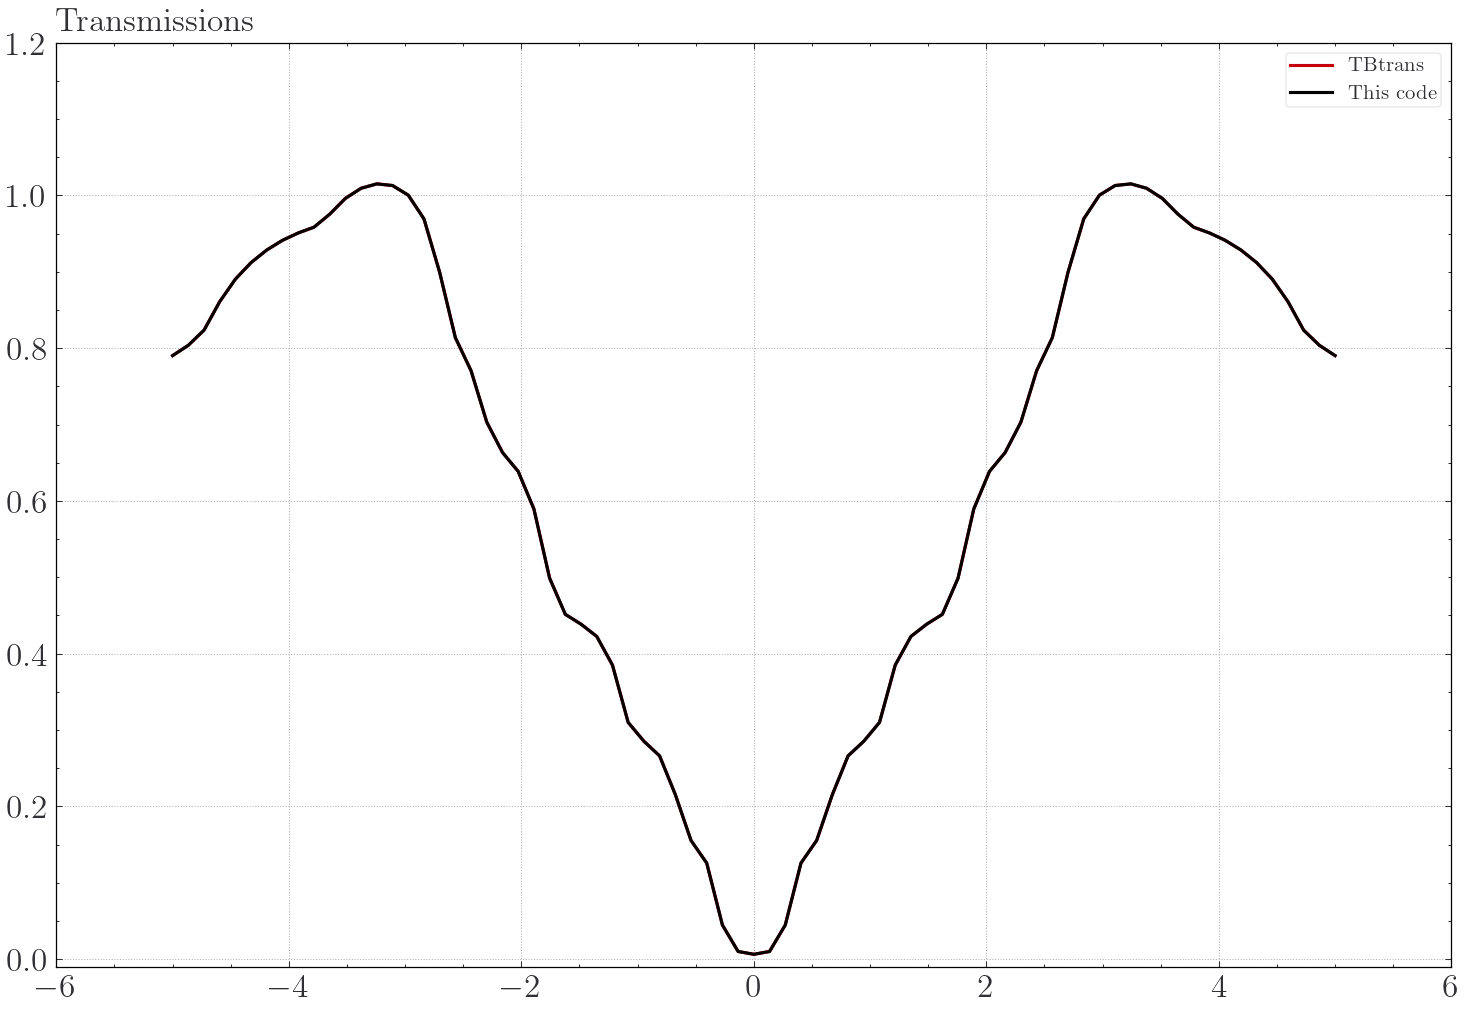

In [10]:
Test.Device.Visualise()
Test.Inspect_Transmission(0,1)
#Test.Lowdin[1].Block(1,1)

In [11]:
dev_H.nsc

array([3, 3, 1], dtype=int32)

### Fitting
When fitting the peaked structure of the contact self-energies, many Lorentzians will end up in a relatively small energy-range. This is good to fit the peaks, but also introduces a high degree of linear dependence between the fitting functions. This results in very large eigenvalues (which we will see shortly) that still fits very well, but are computationally tricky to handle in the propagation. This can be understood as you can cancel Lorentzian with a large weight with an almost identical Lorentzian with the negative weight. Therefore a term that punishes overlap between the Lorentzian basis functions can be added through the "alpha_PO" keyword and introduces an Ad-Hoc term that drives the Lorentzian poles away from each other:

$
Error(\{\epsilon_i, \gamma_i\}_i) = \int  |\mathbf{f}(E) - \sum_{i}\mathbf{\Gamma}_iL(E, \epsilon_i, \gamma_i)|^2 \mathrm{d}E  + \mathrm{alpha\_PO}\cdot\mathrm{Overlap term}
$

In [12]:
#Test.reset_all_fits() # Comment in to reset fits!
NL = 10
min_tol  = -0.0*np.ones(NL)[None,:][np.arange(30)*0,:]
min_tol1 =  min_tol.copy()
min_tol2 =  min_tol.copy()

def run_mini(its):
    Test.Fit(fact = 1.0, Fallback_W = 30.0, NumL = NL,
          fit_mode      = 'all',
          force_PSD     = True,
          force_PSD_tol = [min_tol1, min_tol2],
          use_analytical_jac = True,
          min_method = 'SLSQP',
          ebounds = (-10, 10),
          wbounds = (0.01, 0.8),
          gbounds = (None, None),
          tol = -1,
          options = {'disp':True,'maxiter':its, 
                     'gtol':1e-10,
                     'ftol':1e-10,
                     'iprint':1
                     },
          fit_real_part = False,
          specific_bounds = None,#[{(0 ,2) :[(0.1, 0.11), (4,5)]}, {(0 ,5) :[(-0.1, 0.1), (4,5)]}], 
          alpha_PO = 0.01, 
          )


In [13]:
run_mini(500)

Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

2
#Variables optimized for: 20
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  2846.31354, 4
F,it =  2633.24486, 8
F,it =  1922.38878, 12
BAD LHS: Using pseudo-inverse
F,it =  717.62561, 16
F,it =  364.7634, 20
F,it =  349.97773, 24
F,it =  343.07564, 28
F,it =  342.99836, 32
F,it =  342.85212, 36
F,it =  342.38794, 40
F,it =  341.80502, 44
F,it =  341.7772, 48
F,it =  341.62399, 52
F,it =  341.6239, 56
Optimization terminated successfully    (Exit mode 0)
            Current function value: 341.62389166204764
            Iterations: 56
            Function evaluations: 118
            Gradient evaluations: 56
#Variables optimized for: 20
F,it =  1956.12217, 4
BAD LHS: Using pseudo-inverse
F,it =  1978.69906, 8
F,it =  2015.31653, 12
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  1978.75568, 16


/home/investigator/Desktop/Code/PythonModules/Block_matrices/Block_matrices/Block_matrices.py:101: OptimizeWarning: Unknown solver options: gtol
  x = _sp_minimize(F, X0, method = method, jac = JAC,
/home/investigator/.local/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


F,it =  2014.89799, 20
Optimization terminated successfully    (Exit mode 0)
            Current function value: 899.9214882054457
            Iterations: 26
            Function evaluations: 172
            Gradient evaluations: 22
#Variables optimized for: 20
F,it =  425.31296, 4
F,it =  641.97799, 8
F,it =  670.95482, 12
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  326624787064598.44, 16
F,it =  528.35221, 20
BAD LHS: Using pseudo-inverse
F,it =  600.38917, 24
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  2286373509448027.0, 28
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  10002015365830.545, 32
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  326624787064497.4, 36
BAD LHS: Using pseudo-inverse
BAD LHS: Using pseudo-inverse
F,it =  653249586214810.4, 40
F,it =  348.71288, 44
F,it =  349.0555, 48
F,it =  582.14523, 52
F,it =  362.08255, 56


### The self-energies and transmission

We've proceeded a bit faster now than previously, but we are now at the point where we have the self-energy fits, and we can proceed with the propagation when we wish. We'll however just dwell a but longer with the self-energies. We now have a k-pont sampling we'll have to consider. The transmission is still inspected using the same function as has been used previously, but the Inspect_SE_lorentzian_fit" has the "ik" keyword, which is 0 by default and picks out that particular k-index. We sampled 10-k-points in TBtrans, but because of time-reversal symmetry, there are five district points, which you'll now examine. 

       1. Change ik from 0 to 5 below:
       2. Inspect the transmission function (It is very poorly fitting)

(12, 12)


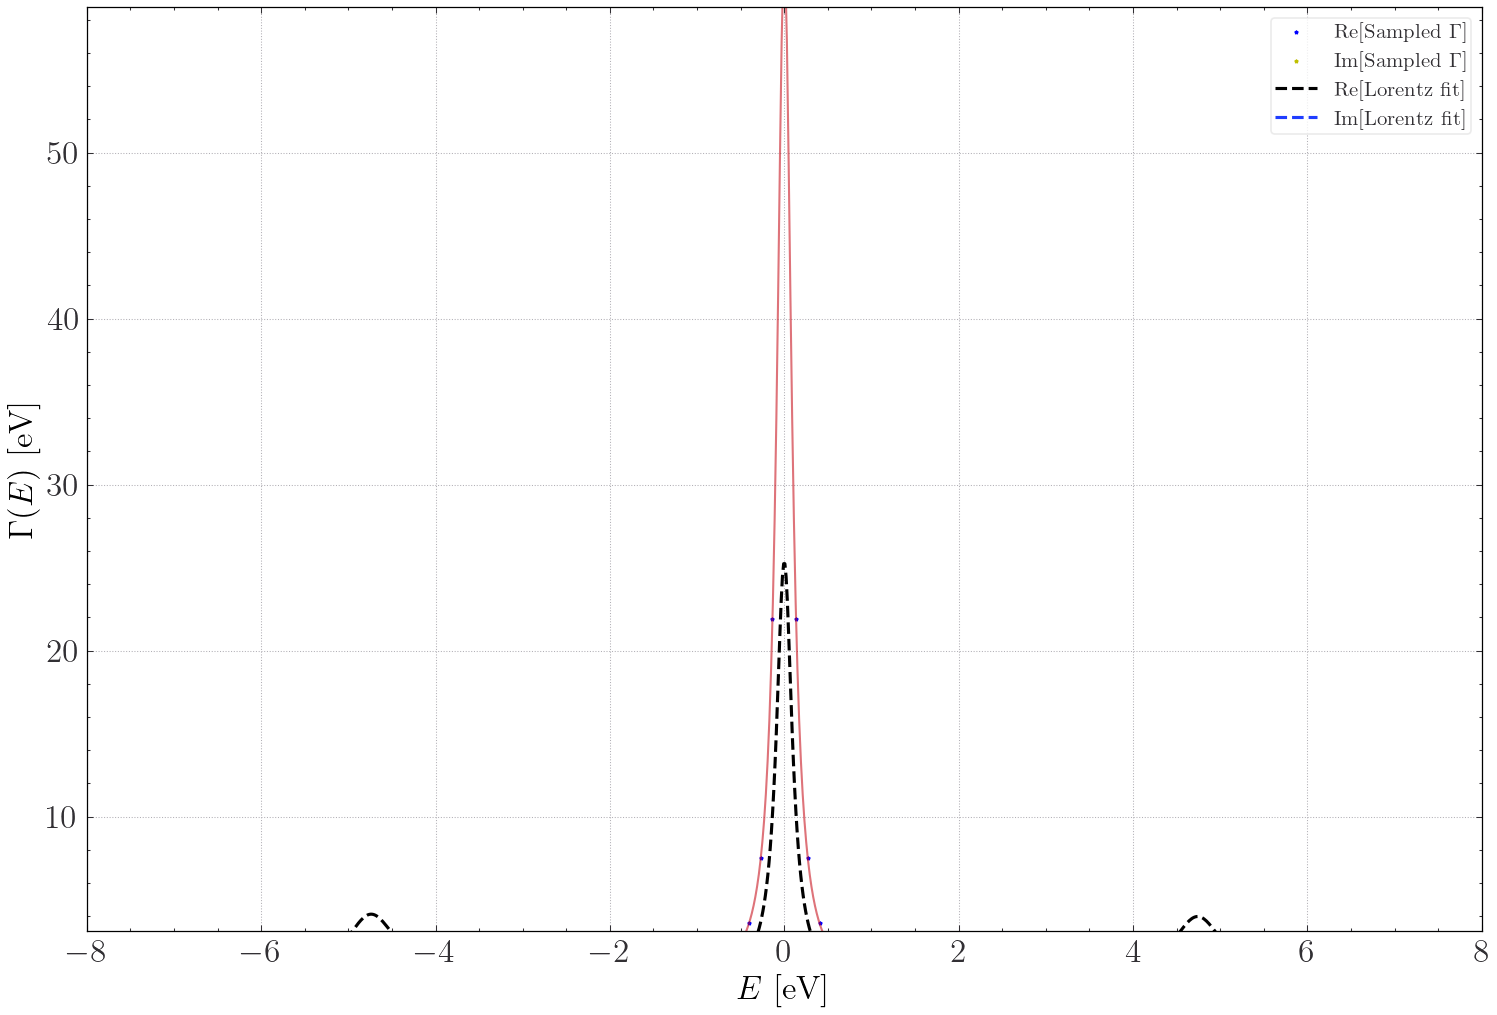

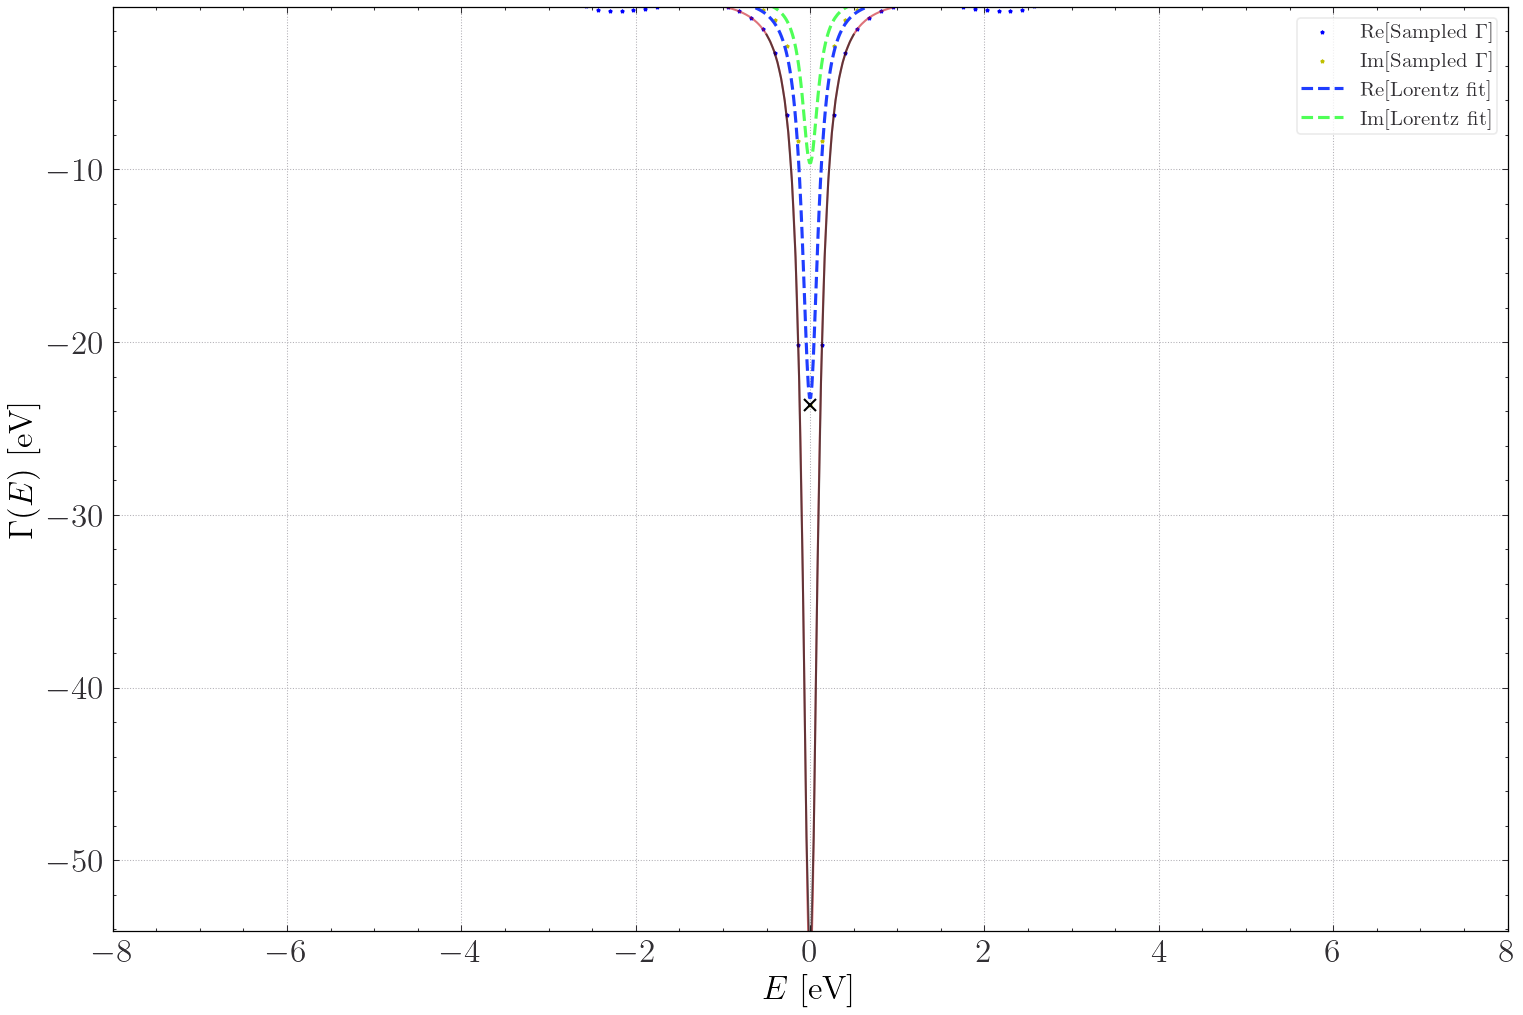

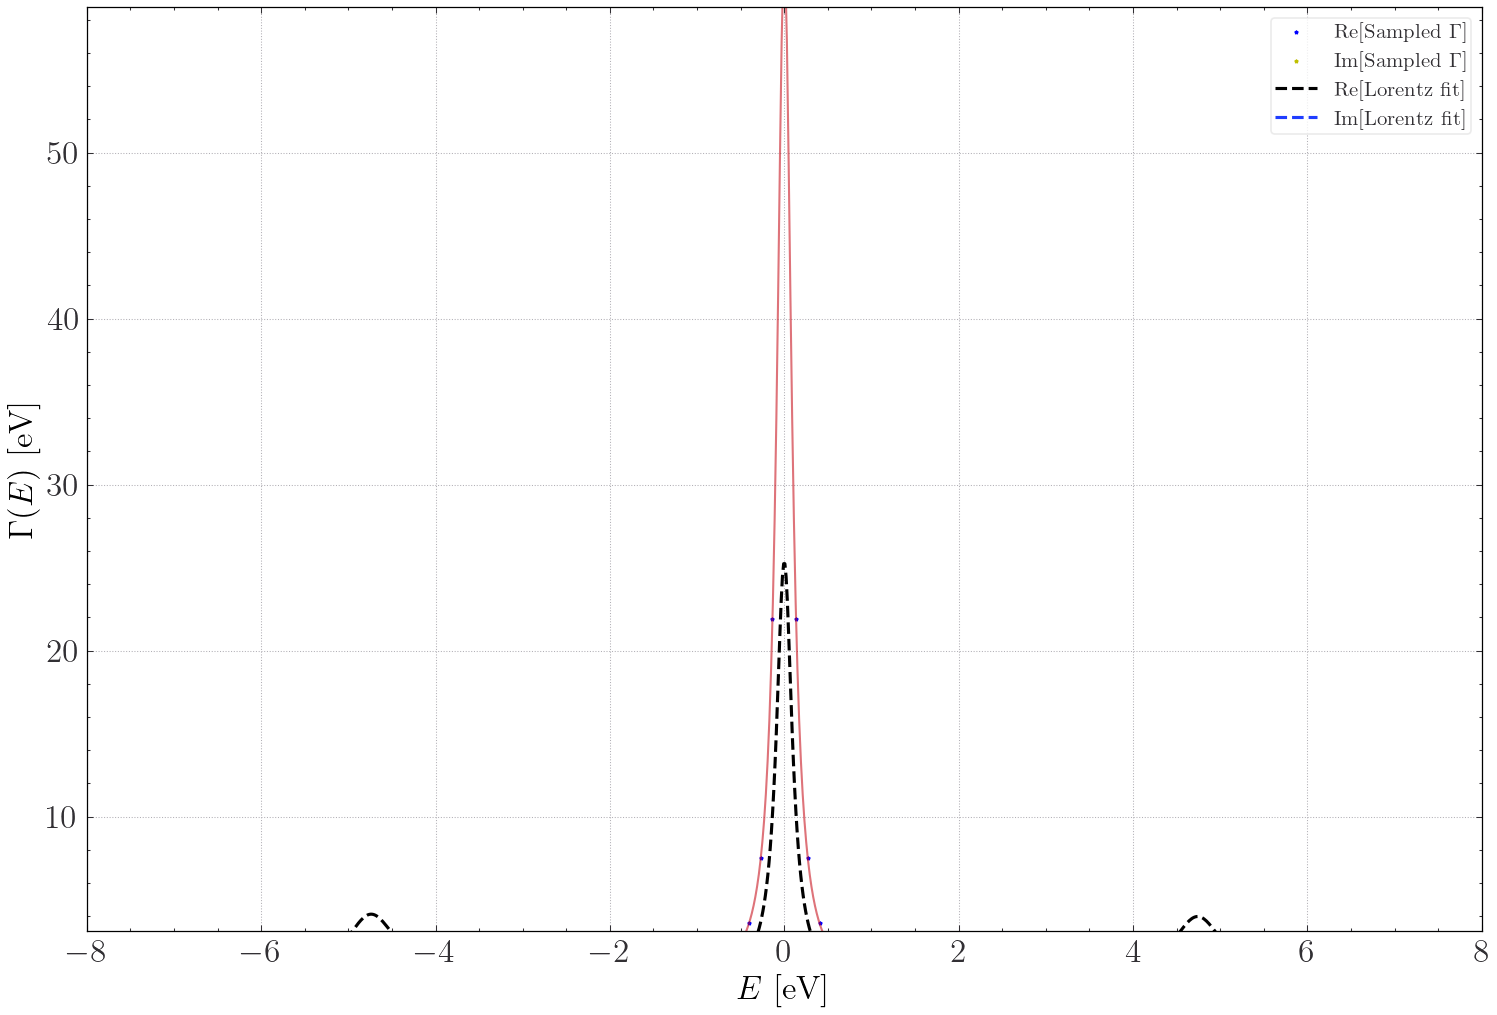

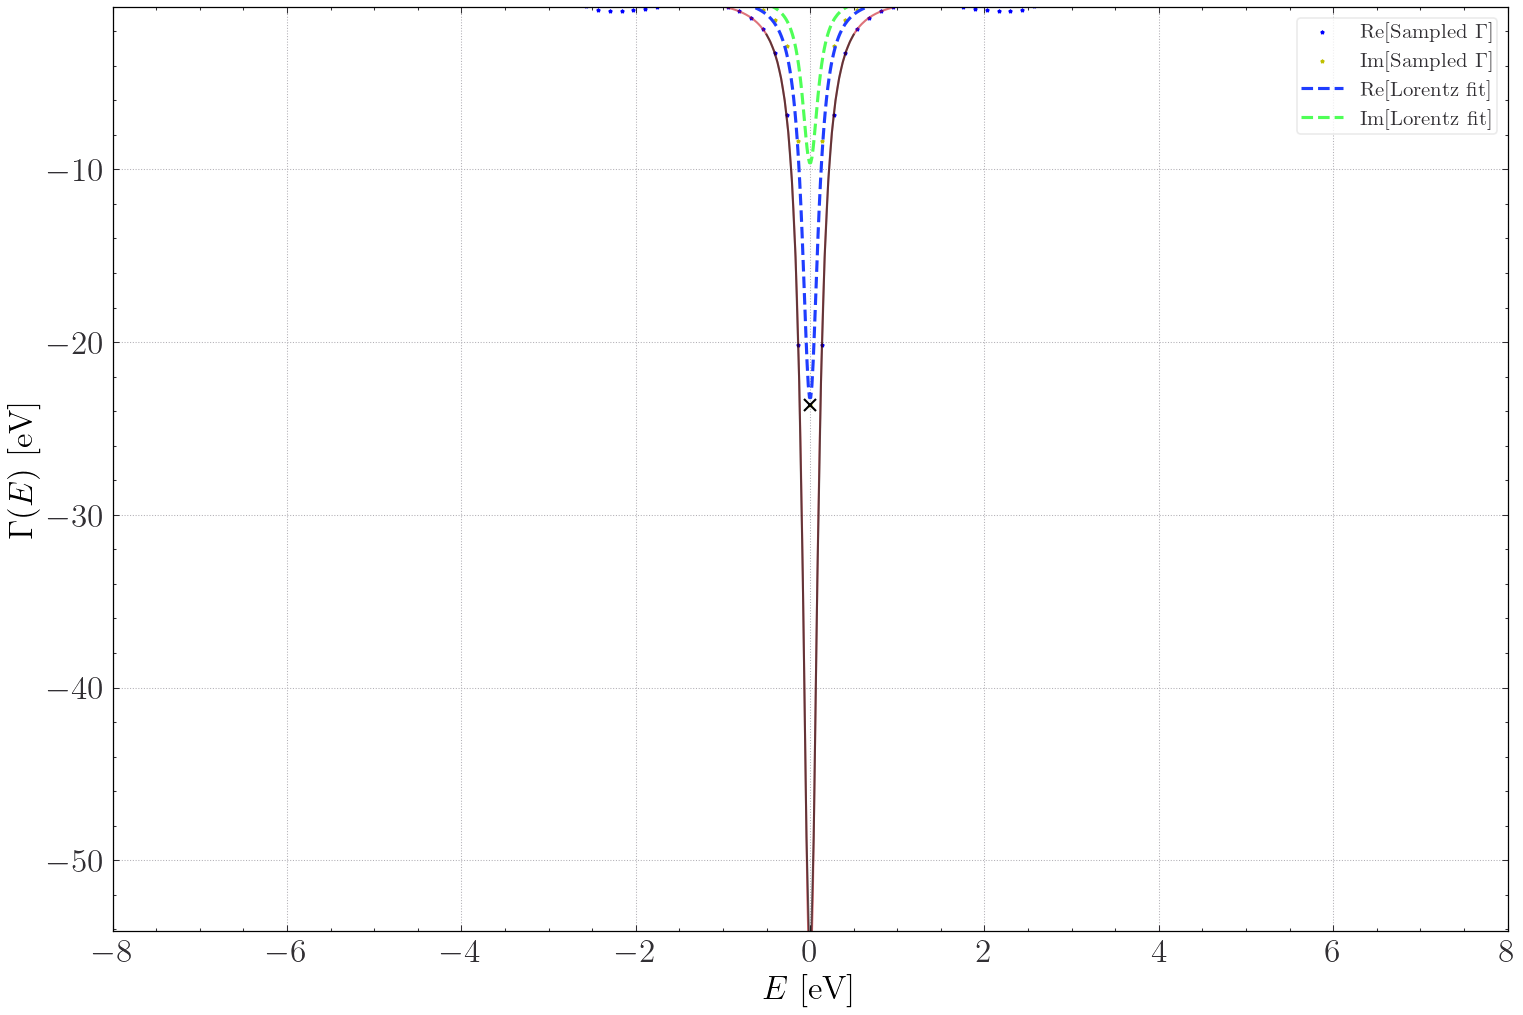

In [14]:
#Test.Inspect_transmission_from_SE_fit(eta = 1e-2); plt.show()
#                              # first five previously explained,  k-idx , min,max energies      
print(Test.fitted_lorentzians[1].is_zero.shape)
IK = 1
Test.Inspect_Lorentzian_fit(1,11,11,0,0,  ik = IK, Emin = -7, Emax = 7,n_samples=1000)
plt.show()
Test.Inspect_Lorentzian_fit(1,11,11,1,0,  ik = IK, Emin = -7, Emax = 7,n_samples=1000)
plt.show()
Test.Inspect_Lorentzian_fit(0,0,0,1,1,    ik = IK, Emin = -7, Emax = 7,n_samples=1000)
plt.show()
Test.Inspect_Lorentzian_fit(0,0,0,1,0,    ik = IK, Emin = -7, Emax = 7,n_samples=1000)


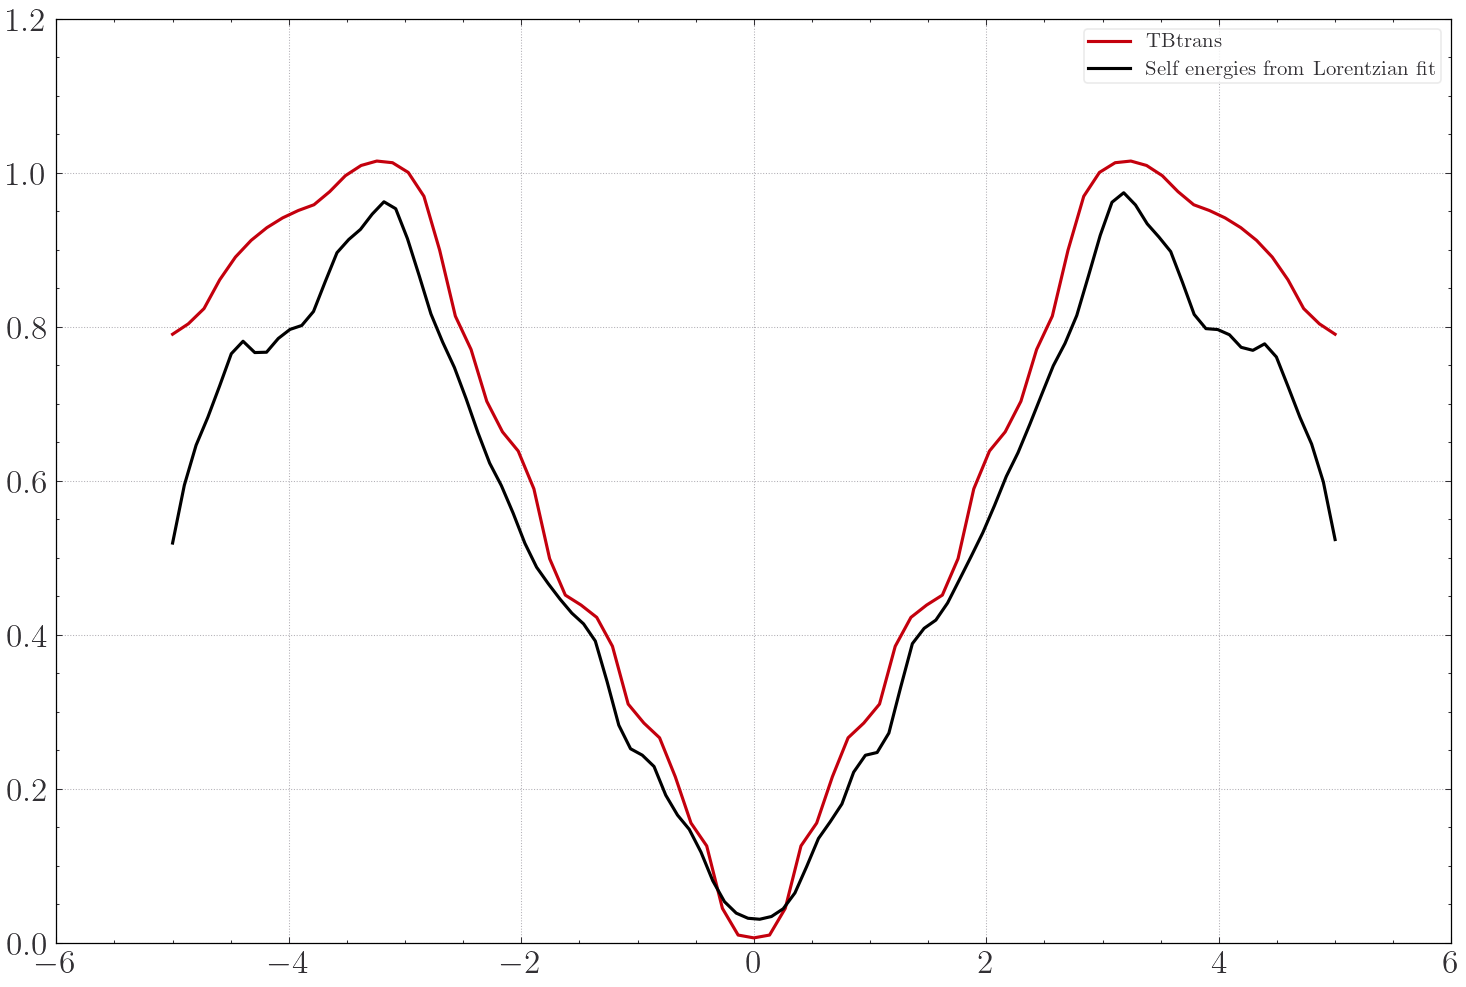

In [15]:
Test.Inspect_transmission_from_hilbert_transform(E=np.linspace(-5,5,100),eta=1e-1)

### Timepropagation
We now go ahead and propagate as we have done previously. We start out with the zero-bias and see how this turns out

In [16]:
Test.tofile('Graphene')

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 137.047229
Minimum of eigenvalues of Lorentzian Gammas: -0.0
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)


/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/TimedependentTransport.py:1185: RuntimeWarning: overflow encountered in exp
  f   = 1/(1 + np.exp((e - mu_dev)/kT_dev))


Minimum distance from Fermi-poles to Lorentzian poles: 0.04702109278720317/n
Minimum distance between Lorentzian poles: 0.334384410960439/n
Minimum value of imaginary part of Lorentzian poles: 0.01


(0.0, 3.0)

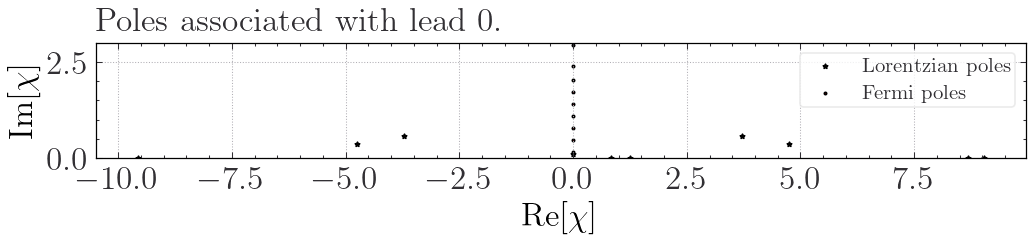

In [17]:
Test.Inspect_Poles(0, ik = 0); plt.ylim([0,3])

In [20]:
!mpirun -np 3 zand Dir=$PWD

Warning from RK4pars: Something went wrong with loading k0nfig
Warning from RK4pars: Something went wrong with loading k0nfig
Warning from RK4pars: Something went wrong with loading k0nfig

  
  ▂▃▄▅▆▇█▓▒░zand (v. 1.0)░▒▓█▇▆▅▄▃▂
  
  Program developed for time-dependent transport in nanostructures 
  at the Technical University of Denmark (DTU).
  
  Please cite this article:
       ***Cool Article Bibtex***  

  
  Author: Aleksander Bach Lorentzen, DTU ( abalo@dtu.dk / aleksander.bl.mail@gmail.com )
  Supervisor: Prof. Mads Brandbyge, DTU.
    - Dr. Nick Papior from DTU compute has constributed with performance tips.
    - Dr. Alexander Croy from Friedrich Schiller University has contributed 
      with methods for consistency checks and steadystate solution. 


  Visit Github.com/AleksBL/?? for tutorials.
  
  Basic function of this program:
  There are two scripts that needs to accompany this program:
 
  The "Initial.py" script, which has the information of the 
  initial and fina

td_info Program Start

sys.argv: ['/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/cmdtools/td_info', 'Dir=/home/investigator/Desktop/TD_stuff/nb_tutorial/TightBinding/T3_Graphene', 'file=Graphene', 'plotcurrent=1', 'label=Current', 'format=png', 'ik=1', 'tmin=-20', 'tmax=100']

[1]
Figure(900x750)


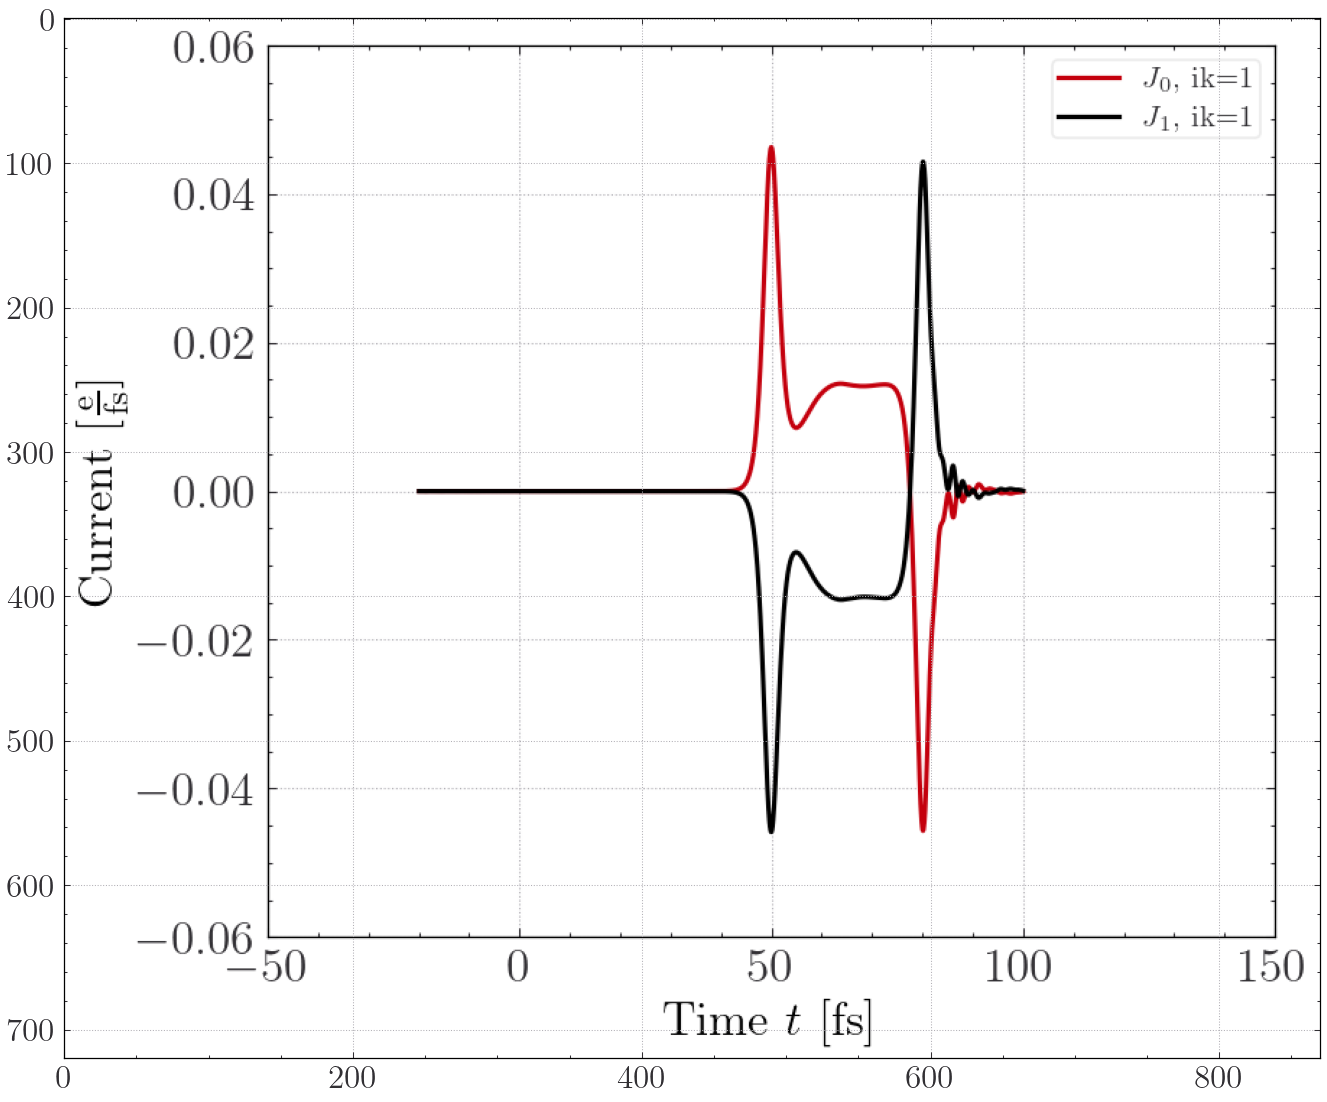

In [21]:
!td_info Dir=$PWD file=Graphene plotcurrent=1 label=Current format=png ik=1 tmin=-20 tmax=100
im = img.imread('CurrentCurrentplot.png')
plt.rcParams['figure.figsize']=(15,9)
plt.imshow(im)


Why do the different K-points respond differently?


        - Consider the Gammas  we plotted before and the Hamiltonian


Go to your terminal and get familiar with the td_info tool.
        
        - try plotdevicecharge=1 
        - try plotdm=1 dm_inds=0,0
You can also use the td_info tool while the calculation is running in another terminal. Its useful for monitoring calculations

In [ ]:
!td_info --help

### SCF and psinought
The initial noise you see in some of the calculations, we can get rid of.
     
     1. Copy the Graphene folder and make a new one called "Gr" 
     2. Go to Inititial.py and set name='Gr' instead
     3. The next steps we do from jupyter, but you can do them in the terminal 
        just as well
Run the SCF code.  This determines the initial density matrix. 
Run the psinought code. This determines the initial $\psi_{k,\alpha x c}$ and $\Omega_{k,\alpha x c\alpha' x' c'}$.
Run SuperZand again, but with the Gr initial state instead. For this do:
    
    1. Go to Initial.py
    2. set usesave=True  
    3. set LoadFromFull=True
    4. Run SuperZand

In [ ]:
!SCF Dir=$PWD file=Gr

In [ ]:
!psinought Dir=$PWD file=Gr add_random=True

In [ ]:
!mpirun -np 3 SuperZand Dir=$PWD

In [ ]:
!td_info Dir=$PWD file=Gr plotcurrent=1 label=Current format=png ik=1
im = img.imread('CurrentCurrentplot.png')
plt.rcParams['figure.figsize']=(15,9)
plt.imshow(im)

### Learned Points

    - Multiple k-points (useful for propagating any quantum numbers that dont mix.  Also spin)
    - Fitting with the built-in fitting tool
    - Using the SCF tool can save time
    - Using the psinought tool can save time
    - Remembering to use "usesave=True" and "LoadFromFull=True" to utilize the output of psinought
    
    